In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import folium
import spaghetti
import esda
import pyproj
from IPython.display import display
import networkx as nx

C:\Users\jsama\miniconda3\envs\nda\Lib\site-packages\spaghetti\network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
#Coursework Part 2


#Load all data between 2014-2016
years = ["2014", "2015", "2016"]
dfs = []
for year in years:
    df = pd.read_csv(f"Datasets/{year}.csv", encoding="latin-1")
    df["year"] = year
    dfs.append(df)
accidents = pd.concat(dfs, ignore_index=True)

#data clean up and keeping only relevant columns
accidents_clean= accidents[[
    "Reference Number",
    "Grid Ref: Easting",
    "Grid Ref: Northing",
    "Accident Date",
    "1st Road Class",
    "Casualty Severity",
    "year"
]].copy()

#Drop rows with missing cooridinates
accidents_clean = accidents_clean.dropna(subset=["Grid Ref: Easting", "Grid Ref: Northing"])

#drop rows with invalid cooridante values
accidents_clean = accidents_clean[(accidents_clean["Grid Ref: Easting"] > 0) & (accidents_clean["Grid Ref: Northing"] > 0)]
print(f"Cleaned accidents: {len(accidents_clean)}")
print(accidents_clean["year"].value_counts().sort_index())

#Drop duplicate rows based on reference number and date
accidents_clean = accidents_clean.drop_duplicates(subset=["Reference Number", "Accident Date"])

print(f"Cleaned accidents: {len(accidents_clean)}")
print(accidents_clean["year"].value_counts().sort_index())


Cleaned accidents: 7746
year
2014    2533
2015    2664
2016    2549
Name: count, dtype: int64
Cleaned accidents: 5841
year
2014    1936
2015    1979
2016    1926
Name: count, dtype: int64


In [3]:
#converting coordinates
#Leeds accident data uses Easting and Northing which is OSMnx cannot use directly
transformer = pyproj.Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)
lons, lats = transformer.transform(
    accidents_clean["Grid Ref: Easting"].values,
    accidents_clean["Grid Ref: Northing"].values
)
accidents_clean = accidents_clean.copy()
accidents_clean["lon"] = lons
accidents_clean["lat"] = lats

print(f"Latitude: {accidents_clean['lat'].min():.4f} to {accidents_clean['lat'].max():.4f}")
print(f"Longitude: {accidents_clean['lon'].min():.4f} to {accidents_clean['lon'].max():.4f}")


Latitude: 53.7043 to 53.9417
Longitude: -1.7772 to -1.3039


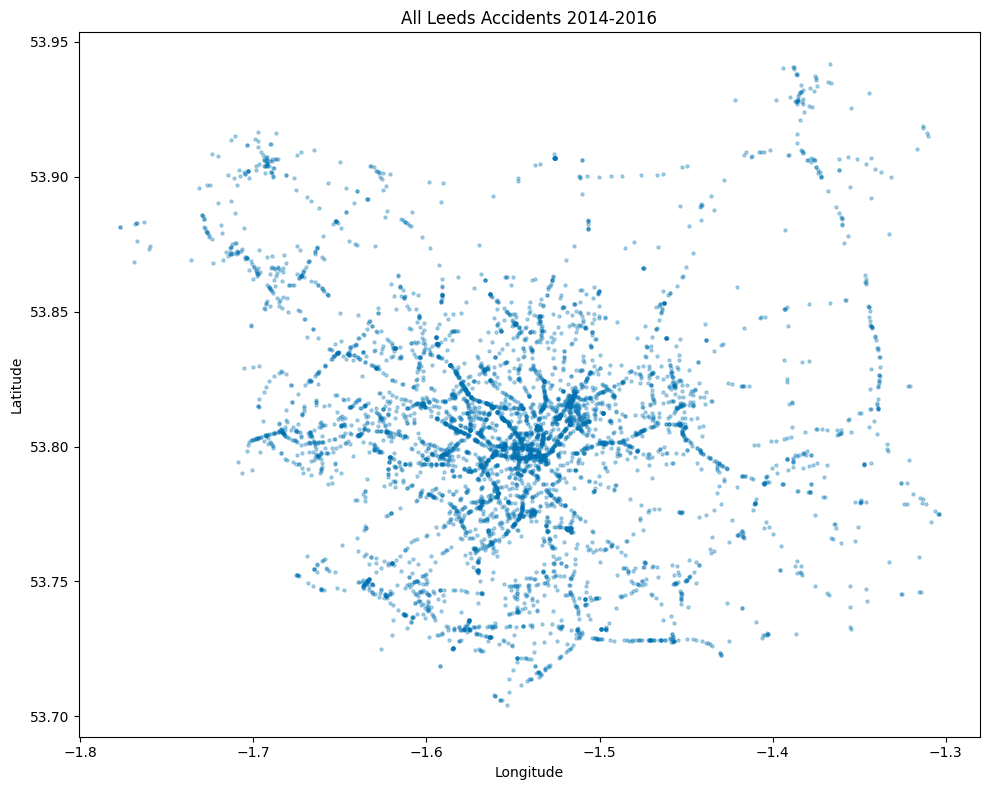


Lat range: 53.704298 to 53.9417

Lon range: -1.777187 to -1.3039


In [4]:
#find hotspot area
#plots accidents to find a dense area with more than 300 accidents
#helps to choose the ~1km^2 area for the analysis
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(accidents_clean['lon'], accidents_clean['lat'],
           alpha=0.3, s=5, color="#0072B2")
ax.set_title("All Leeds Accidents 2014-2016")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("All_Accidents.png", dpi= 150)
plt.show()

print(f"\nLat range: {accidents_clean['lat'].min():4f} to {accidents_clean['lat'].max():.4f}")
print(f"\nLon range: {accidents_clean['lon'].min():4f} to {accidents_clean['lon'].max():.4f}")

In [5]:
#ocunting accidents in leeds city centre area
#centre of leeds is about 53.80 in lat and -1.55 in lon
#1km - 0.009 degrees lat and 0.015 degrees in longitude
centre_lat = 53.80
centre_lon = -1.55
delta_lat = 0.009
delta_lon = 0.015
area_accidents = accidents_clean[
    (accidents_clean['lat'] >= centre_lat - delta_lat) &
    (accidents_clean['lat'] <= centre_lat + delta_lat) &
    (accidents_clean['lon'] >= centre_lon - delta_lon) &
    (accidents_clean['lon'] <= centre_lon + delta_lon) 
]

print(f"Accidents in chosen area: {len(area_accidents)}")
print(f"Bounding Box:")
print(f" Lat: {centre_lat - delta_lat:.2f} to {centre_lat + delta_lat:.2f}")
print(f" Lon: {centre_lon - delta_lon:.2f} to {centre_lon + delta_lon:.2f}")


Accidents in chosen area: 524
Bounding Box:
 Lat: 53.79 to 53.81
 Lon: -1.56 to -1.54


Nodes: 424
Edges: 812


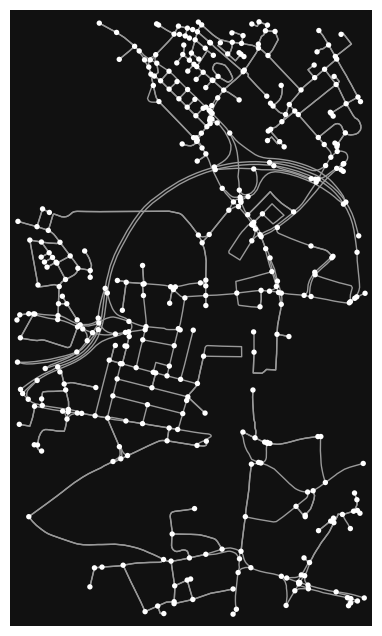

In [6]:
#bbox format is wes, south, east
leeds_graph = ox.graph_from_bbox(
    bbox=(-1.56, 53.79, -1.54, 53.81),
    network_type = "drive")
print(f"Nodes: {leeds_graph.number_of_nodes()}")
print(f"Edges: {leeds_graph.number_of_edges()}")
fig, ax = ox.plot_graph(leeds_graph, save=True, filepath="leeds_road_network.png", dpi= 150)

In [7]:
#Task A= Road network metrics using OSMnx basic stats
area_m2 = 1_000_000 #about 1km^2
leeds_graph_undirected = ox.convert.to_undirected(leeds_graph)

streets_len_total = ox.stats.street_length_total(leeds_graph_undirected)
circuity = ox.stats.circuity_avg(leeds_graph_undirected)
intersection_cnt = ox.stats.intersection_count(leeds_graph_undirected)
streets_per_node = ox.stats.streets_per_node_avg(leeds_graph_undirected)
edge_len_total = ox.stats.edge_length_total(leeds_graph_undirected)
street_seg_count = ox.stats.street_segment_count(leeds_graph_undirected)

node_density = leeds_graph.number_of_nodes() /area_m2
intersection_density = intersection_cnt/area_m2
edge_density = edge_len_total/area_m2
avg_street_length = streets_len_total /street_seg_count

print(f"Street length total: {streets_len_total: .2f} m")
print(f"Avg street length: {avg_street_length:.2f}m")
print(f"Streets per node avg: {streets_per_node: .4f}")
print(f"Intersection count: {intersection_cnt}")
print(f"Intersection density: {intersection_density:.6f} per m^2")
print(f"Edge density: {edge_density:.4f} m/m^2")
print(f"Node density: {node_density:.6f} per m^2")
print(f"Avg circuity: {circuity:.4f}")

Street length total:  40430.81 m
Avg street length: 73.78m
Streets per node avg:  2.7052
Intersection count: 344
Intersection density: 0.000344 per m^2
Edge density: 0.0404 m/m^2
Node density: 0.000424 per m^2
Avg circuity: 1.0769


In [8]:
#Spatial diameter- longest shortest path by geographic distance
#projects graph to metres first for meaningful distrance calculation
leeds_proj = ox.project_graph(leeds_graph)
G_und = ox.convert.to_undirected(leeds_proj)
#use largest connected component to avoid infinite paths between disconnected nodes
largest_cc = max(nx.connected_components(G_und), key=len)
G_sub = G_und.subgraph(largest_cc)

spatial_diam = nx.diameter(G_sub, weight="length")
print(f"Spatial diameter: {spatial_diam:.2f} m")

#planarity check- a planar graph cna be drawn with no crossing edges
#road networks are expected to be near planar but not stricly planar due to bridges tunnels or overpasses
import networkx as nx
G_simple= nx.Graph(leeds_graph)
is_planar, _ = nx.check_planarity(G_simple)
print(f"Is the network planar?? {is_planar}")
#Count nodes with degree > 3 to identify complex intersections (4+ roads meeting)
high_degree = [(n, d) for n, d in G_simple.degree() if d>3]
print(f"Nodes with degree > 3 (complext intersections): {len(high_degree)}")
print(f"Example complex interesections: {high_degree[:3]}")

Spatial diameter: 4337.63 m
Is the network planar?? False
Nodes with degree > 3 (complext intersections): 44
Example complex interesections: [(9237404, 4), (9237600, 4), (9791509, 4)]


C:\Users\jsama\miniconda3\envs\nda\Lib\site-packages\spaghetti\network.py:3412: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  pts = [cg.shapes.Point((p.x, p.y)) for p in pts_objs]
C:\Users\jsama\miniconda3\envs\nda\Lib\site-packages\spaghetti\util.py:572: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  return cg.Chain([cg.Point(_vcoords[v]) for v in _vs] if _vcoords else _vs)
C:\Users\jsama\miniconda3\envs\nda\Lib\site-packages\libpysal\cg\shapes.py:1025: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._bounding_box = Rectangle(


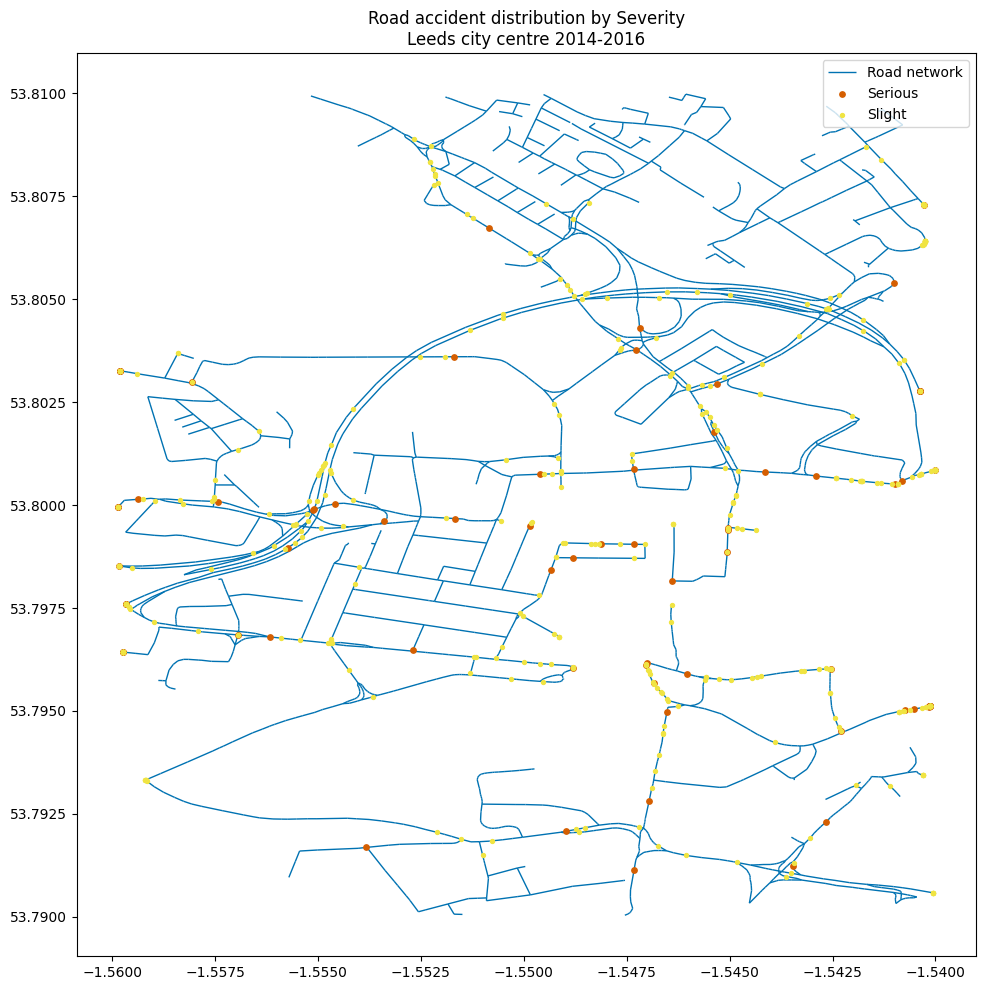


Total accidents snapped to network: 524
Severity breakdown:
Casualty Severity
Slight     451
Serious     73
Name: count, dtype: int64


In [9]:
#Task B
#Question1 - Plot accident distribution on the road network
from geopandas import GeoDataFrame
from shapely.geometry import Point, LineString
import spaghetti
import esda

#Add missing edge geometries using node cooridinates
#some of the OSMnx edges lack geometry so a straiht  line is used as approximation
x_values = nx.get_node_attributes(leeds_graph, "x")
y_values = nx.get_node_attributes(leeds_graph, "y")
geometric_graph = list(leeds_graph.edges(data=True))

for e in geometric_graph:
    if "geometry" not in e[2]:
        e[2]["geometry"] = LineString([
            Point(x_values[e[0]], y_values[e[0]]), Point(x_values[e[1]], y_values[e[1]])
        ])
#build spaghetti network from road geometries 
road_lines = [x[2] for x in geometric_graph]
roads_gdf = GeoDataFrame(pd.DataFrame(road_lines))
leeds_network = spaghetti.Network(in_data=roads_gdf)

#Map Text severity to numeric weight
#Fatal most visually prominent, Slight Least
severity_map= {"Fatal" : 3, "Serious": 2, "Slight": 1}
area_accidents  = area_accidents.copy()
area_accidents["severity_weight"] = area_accidents["Casualty Severity"].map(severity_map)

#Create accident points GeoDataFrame
accident_points = GeoDataFrame(
    geometry = [Point(lon, lat) for lon, lat in zip(area_accidents["lon"], area_accidents["lat"])]
)

#Snap accidents to nearest road on the network 
leeds_network.snapobservations(accident_points, "accidents")
#Get snapped accident location for plotting
nodes_df, edges_df = spaghetti.element_as_gdf(
    leeds_network, vertices= True, arcs=True
)
snapped_accidents = spaghetti.element_as_gdf(
    leeds_network, pp_name="accidents", snapped=True)

#merge severity weights for plotting
snapped_accidents["severity_weight"] = area_accidents["severity_weight"].values
#plot road network with accidents coloured and sized by severity
fig, ax = plt.subplots(figsize=(10,10))
edges_df.plot(ax =ax, color="#0072B2", linewidth=1, zorder= 0, label="Road network")

for weight, size, color, label in [
    #(3, 8, "#E69F00", "Fatal"),
    (2,15, "#D55E00", "Serious"),
    (1,8, "#F0E442", "Slight")
]:
    mask= snapped_accidents["severity_weight"] == weight
    if mask.any():
        snapped_accidents[mask].plot(
            ax=ax, color = color, marker= "o",
            markersize = size, zorder =2, label =label
        )
ax.legend(loc="upper right")
ax.set_title("Road accident distribution by Severity\n"
                 "Leeds city centre 2014-2016")
plt.tight_layout()
plt.savefig("accident_distribution.png", dpi = 150)
plt.show()

print(f"\nTotal accidents snapped to network: {len(snapped_accidents)}")
print(f"Severity breakdown:\n{area_accidents['Casualty Severity'].value_counts()}")



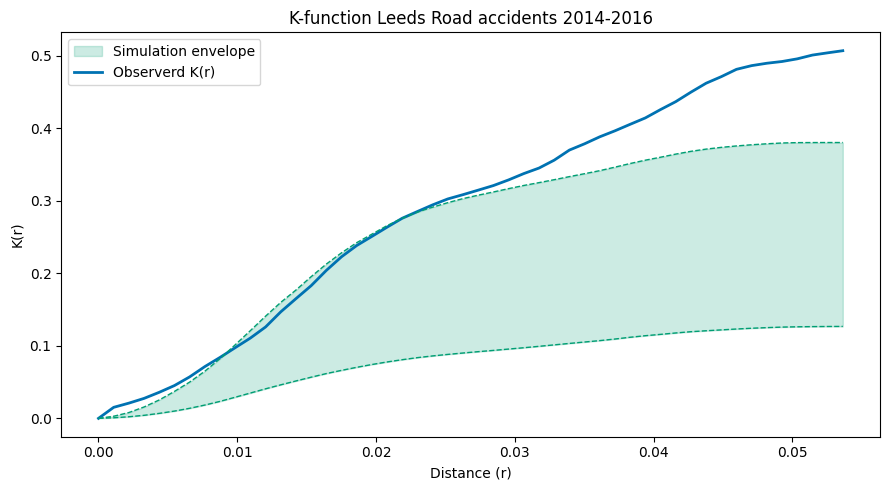

Network accident density (lambda): 1031.793208
Moran's I: 0.0786
Expected(random): -0.0004
P-value: 0.0040
Statistically significant: True

Accidents show significant positive spatial autocorrelation
Roads with many accidents tend to be near other high accident roads
K-function: accidents are more clustered than random expectations


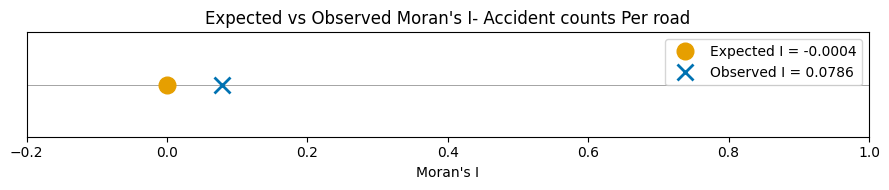

In [10]:
#Task b continued, second question= K function and moran's I
#K function tests whether accidents cluster more than random expectations on the network
#better option than Eculidean k function as it repsects road contrainsts
#nsteps= 50 gives smooth curvie, permutation = 99 for reaiable envelope
kres = leeds_network.GlobalAutoK(
    leeds_network.pointpatterns["accidents"], 
    nsteps = 50, permutations = 99
)
#plot k function with shaded envelope between upper and lower bounds
#shaded area shows range expected under complete spatial randomness
fig, ax = plt.subplots(figsize=(9,5))
ax.fill_between(kres.xaxis, kres.lowerenvelope, kres.upperenvelope, alpha=0.2, color = "#009E73", label= "Simulation envelope")
ax.plot(kres.xaxis, kres.observed, color="#0072B2", linewidth = 2, label="Observerd K(r)")
ax.plot(kres.xaxis, kres.upperenvelope, color = "#009E73", linestyle="--", linewidth=1)
ax.plot(kres.xaxis, kres.lowerenvelope, color="#009E73", linestyle="--", linewidth=1)

ax.legend(loc="best")
ax.set_xlabel("Distance (r)")
ax.set_ylabel("K(r)")
ax.set_title("K-function Leeds Road accidents 2014-2016")
plt.tight_layout()
plt.savefig("k_function.png", dpi = 150)
plt.show()
print(f"Network accident density (lambda): {kres.lam:.6f}")

#moran's I=  does high accident count on road correlate with high counts on connecting roads?
#edge adjacency matrix used as spatial weights
pointpat= leeds_network.pointpatterns["accidents"]
counts = leeds_network.count_per_link(pointpat.obs_to_arc, graph= False)
weights = leeds_network.w_network
edges = weights.neighbors.keys()
values = [counts[edge] if edge in counts.keys() else 0.
          for index, edge  in enumerate(edges)]
moran = esda.moran.Moran(values, weights)

#Expected moran's I under complete spatial randomeness =-1/(n-1)
expected_I = -1/(len(values) -1)
print(f"Moran's I: {moran.I:.4f}")
print(f"Expected(random): {expected_I:.4f}")
print(f"P-value: {moran.p_sim:.4f}")
print(f"Statistically significant: {moran.p_sim <0.05}")
#interpret results
if moran.p_sim <0.05:
    if moran.I >0:
        print("\nAccidents show significant positive spatial autocorrelation")
        print("Roads with many accidents tend to be near other high accident roads")
    else:
        print("\nAccidents show significant negative spatial autocorrelation")
else:
    print("\nNo significant spatial autocorrelation detected")
if kres.observed[-1] > kres.upperenvelope[-1]:
    print("K-function: accidents are more clustered than random expectations")
elif kres.observed[-1] < kres.lowerenvelope[-1]:
    print("K-function: accidents are more uniform than random expectation")
else: 
    print("K-function: accidents follow random distribution")
#plot observed vs expected MOran's I on a number line
fig, ax = plt.subplots(figsize =(9,2))
ax.axhline(0, color="gray", linewidth= 0.5)
ax.plot(expected_I, 0, "o", color="#E69F00", markersize=12, label=f"Expected I = {expected_I:.4f}")
ax.plot(moran.I, 0, "x", color="#0072B2", markersize = 12, markeredgewidth=2, label=f"Observed I = {moran.I:.4f}")

ax.set_xlim(-0.2, 1)
ax.set_xlabel("Moran's I")
ax.set_yticks([])
ax.legend(loc="upper right")
ax.set_title("Expected vs Observed Moran's I- Accident counts Per road")
plt.tight_layout()
plt.savefig("moransI.png", dpi = 150)
plt.show()

          
        


Total fractions calculated: 524
Sample fractions: [0.03086844 0.         0.         0.         0.        ]


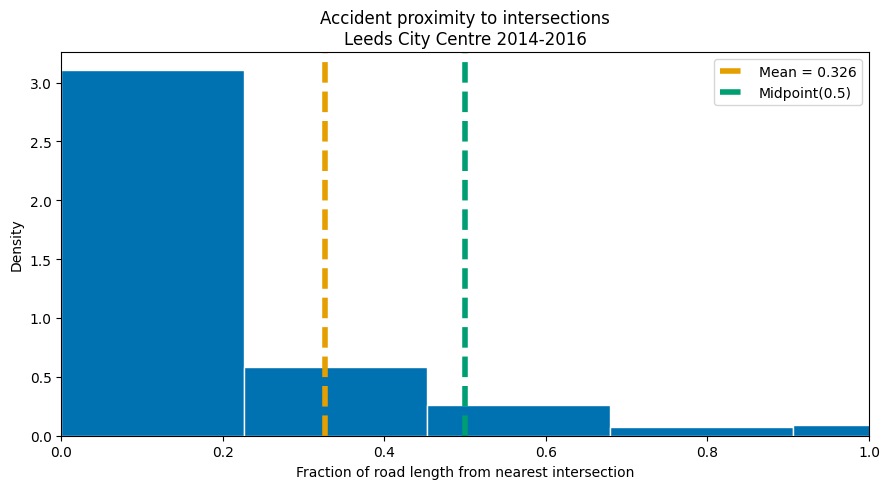

Mean fraction from nearest intersection: 0.3264
Median fraction: 0.0453
% of accidents in first quarter of road: 72.3%
% of accidents near intersections (<10% of road):59.4%


In [11]:
#task b- q3: accident proximity to intersections
import numpy as np
fractions=[]
edges_df_q3 = spaghetti.element_as_gdf(leeds_network, arcs = True)
edges_df_q3["length"] = edges_df_q3.geometry.length
obs_to_arc_inverted={}
for arc_tuple, obs_dict in pointpat.obs_to_arc.items():
    for obs_id in obs_dict.keys():
        obs_to_arc_inverted[obs_id] = arc_tuple

for obs_id, vertex_distances in pointpat.dist_to_vertex.items():
    if obs_id in obs_to_arc_inverted:
        arc_tuple = obs_to_arc_inverted[obs_id]
        #find matching edge in edges_df_q3
        arc_idx = list(pointpat.obs_to_arc.keys()).index(arc_tuple)
        if arc_idx < len(edges_df_q3):
            edge_length = edges_df_q3.iloc[arc_idx].geometry.length
            min_dist = min(vertex_distances.values())
            if edge_length > 0:
                fraction = min_dist/edge_length
                fractions.append(fraction)

fractions = np.array(fractions)
print(f"Total fractions calculated: {len(fractions)}")
print(f"Sample fractions: {fractions[:5]}")

#Plot distribution of fractional distances
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(fractions, bins = 30, color = "#0072B2", edgecolor="white", density=True)
ax.axvline(fractions.mean(), color= "#E69F00",linewidth=4, linestyle="--", label=f"Mean = {fractions.mean():.3f}")
ax.axvline(0.5, color="#009E73", linewidth=4, linestyle="--", label="Midpoint(0.5)")
ax.set_xlabel("Fraction of road length from nearest intersection")
ax.set_ylabel("Density")
ax.set_title("Accident proximity to intersections\n"
             "Leeds City Centre 2014-2016")
ax.set_xlim(0,1)
ax.legend()
plt.tight_layout()
plt.savefig("intersection_prox.png", dpi= 150)
plt.show()

print(f"Mean fraction from nearest intersection: {fractions.mean():.4f}")
print(f"Median fraction: {np.median(fractions):.4f}")
print(f"% of accidents in first quarter of road: "
      f"{(fractions<0.25).mean()*100:.1f}%")
print(f"% of accidents near intersections (<10% of road):"
      f"{(fractions<0.10).mean()*100:.1f}%")


Nodes near accidents: 157
Low accident nodes available: 267

Selected seed nodes: [151917380, 247353857, 9791227, 643936]
Seed 1: node 151917380 at (-1.55075, 53.80860)
Seed 2: node 247353857 at (-1.54541, 53.80724)
Seed 3: node 9791227 at (-1.55440, 53.79739)
Seed 4: node 643936 at (-1.54298, 53.79419)


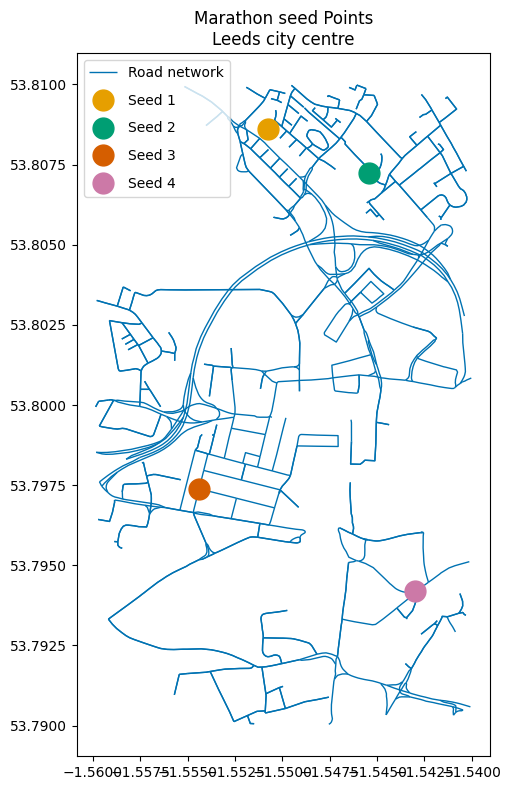

In [12]:
#task C, Q1: Select seed points for marahon voronoi cells
#low accident density = away from high accident roads, evenly spread across network
import numpy as np
nodes_gdf, edges_gdf = ox.graph_to_gdfs(leeds_graph)

#identify nodes near accident locations to avoid seed points
high_accident_nodes = set()
for _, accident in area_accidents.iterrows():
    nearest_node= ox.nearest_nodes(leeds_graph, accident["lon"], accident["lat"])
    high_accident_nodes.add(nearest_node)
print(f"Nodes near accidents: {len(high_accident_nodes)}")
#filter to nodes away from high accident areas
all_nodes = list(leeds_graph.nodes())
low_accident_nodes = [n for n in all_nodes if n not in high_accident_nodes]
print(f"Low accident nodes available: {len(low_accident_nodes)}")
#get coordinates for candidate nodes
node_coords = {n: (leeds_graph.nodes[n]["x"], leeds_graph.nodes[n]["y"])
               for n in low_accident_nodes}
#divide net into 4 quadrants by medain lonlat and pick centroid node from each to ensure seeds are evenly spread
lons =[v[0] for v in node_coords.values()]
lats =[v[1] for v in node_coords.values()]
mid_lon = np.median(lons)
mid_lat =np.median(lats)

quadrants = {0: [], 1:[], 2:[], 3:[]}
for node, (lon, lat) in node_coords.items():
    if lon <= mid_lon and lat >= mid_lat:
        #top left
        quadrants[0].append(node)
    elif lon > mid_lon and lat >=mid_lat:
        #top right
        quadrants[1].append(node)
    elif lon <= mid_lon and lat<mid_lat:
        #bottom left
        quadrants[2].append(node)
    else:
        #bottom right
        quadrants[3].append(node)

#to pick the node closest to each quadrants centroid as seed
seed_nodes= []
for q, nodes in quadrants.items():
    if nodes:
        q_lons=[node_coords[n][0] for n in nodes]
        q_lats =[node_coords[n][1] for n in nodes]
        q_centre_lon = np.mean(q_lons)
        q_centre_lat = np.mean(q_lats)
        #squared Euclidean distance
        closest = min(nodes, key=lambda n: (node_coords[n][0]- q_centre_lon)**2 + (node_coords[n][1] - q_centre_lat)**2)
        seed_nodes.append(closest)

print(f"\nSelected seed nodes: {seed_nodes}")
for i, node in enumerate(seed_nodes):
    x = leeds_graph.nodes[node]["x"]
    y = leeds_graph.nodes[node]["y"]
    print(f"Seed {i+1}: node {node} at ({x:.5f}, {y:.5f})")

#visualise seeds points on the road net
cell_colours = ["#E69F00", "#009E73", "#D55E00", "#CC79A7"]
fig, ax = plt.subplots(figsize =(6,8))
edges_gdf.plot(ax= ax, color="#0072B2", linewidth=1, zorder=0, label="Road network")
for i, node in enumerate(seed_nodes):
    x= leeds_graph.nodes[node]["x"]
    y= leeds_graph.nodes[node]["y"]
    ax.plot(x, y, "o", color=cell_colours[i], markersize = 15, zorder=3, label=f"Seed {i+1}")
ax.legend(loc="upper left", labelspacing = 1)
ax.set_title("Marathon seed Points\nLeeds city centre")
plt.tight_layout()
plt.savefig("seed_points.png", dpi = 150)
plt.show()


    
        


Cell 1: 110 nodes
Cell 2: 78 nodes
Cell 3: 158 nodes
Cell 4: 78 nodes


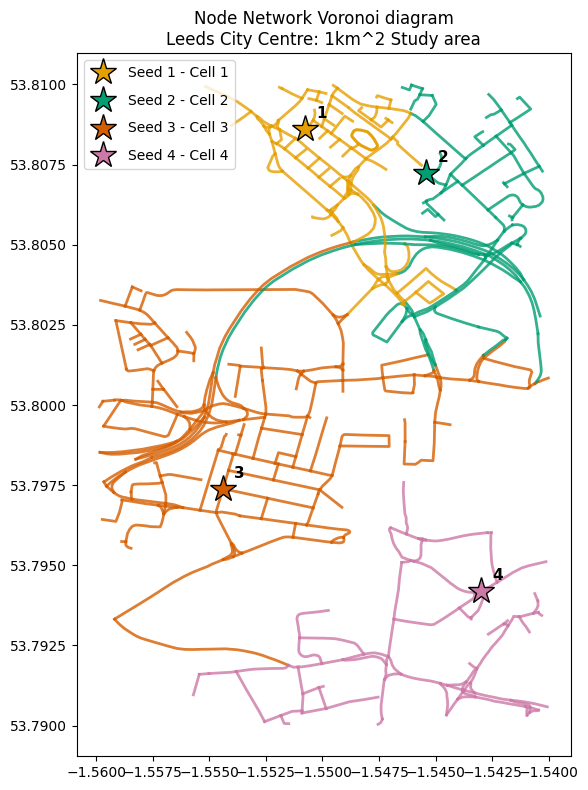

In [13]:
#question 2: voronoi diagram
#node net voronoi because
#seed points = nodes
#marathon routes follow roads so net distance more meaningful than euclidean 
#partitioning by shortest path length along the roads reflects real travel distance

import networkx as nx
G_und = leeds_graph.to_undirected()
#assign each node to nearest seed by shortest path distance along roads
voronoi_assignment = {}
for node in G_und.nodes():
    min_dist = float("inf")
    nearest= None
    for i, seed in enumerate(seed_nodes):
        try:
            d = nx.shortest_path_length(G_und, seed, node, weight = 'length')
            if d < min_dist:
                min_dist = d
                nearest = i
        except nx.NetworkXNoPath:
            continue
    voronoi_assignment[node] = nearest

#print cell sizes
for i in range(4):
    count= sum(1 for c in voronoi_assignment.values() if c ==i)
    print(f"Cell {i+1}: {count} nodes")

#vornoi cells visualisation, edges coloured by cell assignment of their origin node
fig, ax = plt.subplots(figsize=(6,8))
for u, v, data in G_und.edges(data=True):
    cell = voronoi_assignment.get(u)
    colour = cell_colours[cell] if cell is not None else "gray"
    if "geometry" in data:
        xs, ys = data["geometry"].xy
        ax.plot(xs, ys, color= colour, linewidth=2, alpha=0.8)
    else: 
        ax.plot([G_und.nodes[u]["x"], G_und.nodes[v]["x"]],
        [G_und.nodes[u]["y"], G_und.nodes[v]["y"]],
        color = colour, linewidth=2, alpha=0.8)
#plot seed nodes as stars
for i, node in enumerate(seed_nodes):
    x = leeds_graph.nodes[node]["x"]
    y = leeds_graph.nodes[node]["y"]
    ax.plot(x,y, "*", color = cell_colours[i], markersize=20, zorder=5, markeredgecolor="black", markeredgewidth=1, label=f"Seed {i+1} - Cell {i+1}")
    #to show clear points (stars)
    ax.annotate(str(i+1), (x,y), textcoords="offset points", xytext=(8,8), fontsize=11, fontweight="bold", color="black")

ax.legend(loc="upper left", labelspacing = 1)
ax.set_title("Node Network Voronoi diagram\nLeeds City Centre: 1km^2 Study area")
plt.tight_layout()
plt.savefig("voronoi_1km.png", dpi=150)
plt.show()
                



In [14]:
#question 3 and 4= attempt to find about 42km circular routes within each voronoi cell
#tolerance: +-500m 
#approach used here: random walk accumulutaing distance, check if closing the loop hits target

import random 
def find_circular_route(G, seed, target_m=42000, tolerance=500, max_iter=300, rand_seed=42):
    random.seed(rand_seed)
    #work on the connected component containing the seed
    comps = list(nx.connected_components(G))
    seed_comp = next((G.subgraph(c).copy() for c in comps if seed in c), None)
    if seed_comp is None or seed not in seed_comp:
        return None, 0
    cell_road = sum(d.get("length", 0) for u, v, d in seed_comp.edges(data=True))
    print(f" road in cell component: {cell_road/1000:.2f}km")
    best_route = None
    best_err = float("inf")
    for _ in range(max_iter):
        path=[seed]
        total = 0
        current = seed
        while total < target_m + tolerance:
            #check if closing the loop now would hit target distrance
            try:
                ret_dist = nx.shortest_path_length(seed_comp, current, seed, weight="length")
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                break
            candidate_total = total + ret_dist
            if abs(candidate_total - target_m) <= tolerance:
                try:
                    ret_path = nx.shortest_path(seed_comp, current, seed, weight="length")
                    full_dist = total+nx.shortest_path_length(seed_comp, current, seed, weight="length")
                    err = abs(full_dist - target_m)
                    if err < best_err:
                        best_err = err
                        best_route = (path + ret_path[1:], full_dist)
                    if err <= tolerance:
                        return best_route[0], best_route[1]
                except Exception:
                    pass
            #random walk step to next neighbour
            neighbours = list(seed_comp.neighbors(current))
            if not neighbours:
                break
            next_node= random.choice(neighbours)
            edge_data = seed_comp.get_edge_data(current, next_node)
            if isinstance(edge_data, dict) and 0 in edge_data:
                elen = edge_data[0].get("length", 50)
            elif edge_data:
                elen = edge_data.get("length", 50)
            else:
                elen = 50
            total += elen
            path.append(next_node)
            current = next_node
    if best_route:
        return best_route
    return None, 0

#attempt finding route for each cell on original 1km^2 graph
print("Route finding on 1km^2 graph \n")
routes_1km = {}
for i in range(4):
    cell_nodes = [n for n, c in voronoi_assignment.items() if c ==i]
    cell_subgraph = G_und.subgraph(cell_nodes).copy()
    print(f"Cell {i+1} (seed {seed_nodes[i]}):")
    route, dist = find_circular_route(cell_subgraph, seed_nodes[i])
    if route and abs(dist -42000) <= 500:
        routes_1km[i] = (route, dist)
        print(f" route found: {dist/1000:.2f}km\n")
    else:
        routes_1km[i]=None
        print(f" no valid route found :(((( best distance: {dist/1000:.2f}km\n")
        
          
          
        

                    
                    

Route finding on 1km^2 graph 

Cell 1 (seed 151917380):
 road in cell component: 6.69km
 route found: 41.52km

Cell 2 (seed 247353857):
 road in cell component: 6.76km
 route found: 41.52km

Cell 3 (seed 9791227):
 road in cell component: 15.80km
 route found: 41.56km

Cell 4 (seed 643936):
 road in cell component: 6.63km
 route found: 41.61km



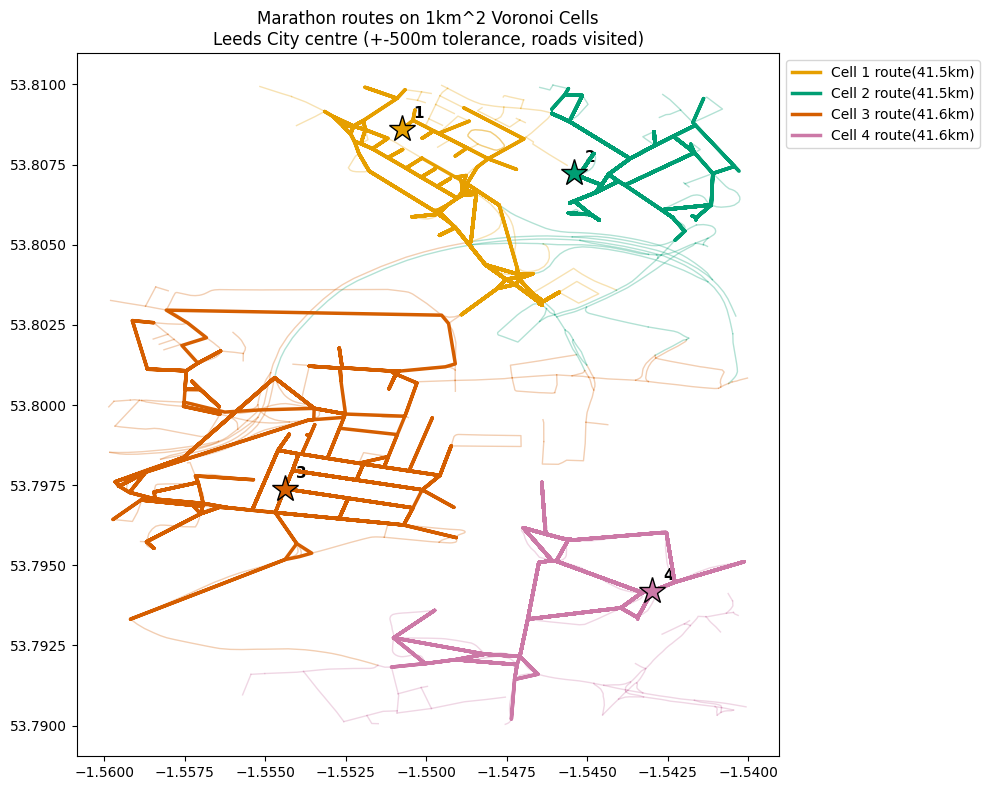

In [15]:
#visualisation of q3/4
fig, ax = plt.subplots(figsize=(10,8))

#draw voronoi cell edges in background
for u, v, data in G_und.edges(data=True):
    cell = voronoi_assignment.get(u)
    color = cell_colours[cell] if cell is not None else "gray"
    if "geometry" in data:
        xs, ys = data["geometry"].xy
        ax.plot(xs, ys, color= color, linewidth=1, alpha=0.3)
    else:
        ax.plot([G_und.nodes[u]["x"], G_und.nodes[v]["x"]],
                 [G_und.nodes[u]["y"], G_und.nodes[v]["y"]],
                  color=color, linewidth=1, alpha=0.3)
#overlay marathon routes
for i, result in routes_1km.items():
    if result is None:
        continue
    route, dist = result
    rx=[G_und.nodes[n]["x"] for n in route]
    ry=[G_und.nodes[n]["y"] for n in route]
    ax.plot(rx, ry, color = cell_colours[i], linewidth=2.5, zorder = 4, label=f"Cell {i+1} route({dist/1000:.1f}km)")

#plot seed nodes as stars
for i, node in enumerate(seed_nodes):
    x=leeds_graph.nodes[node]["x"]
    y=leeds_graph.nodes[node]["y"]
    ax.plot(x, y, "*", color=cell_colours[i], markersize=20, zorder=6, markeredgecolor="black", markeredgewidth=1)
    ax.annotate(str(i+1), (x,y), textcoords="offset points", 
                xytext=(8,8), fontsize=11, fontweight="bold", color="black")
ax.legend(loc="upper left", bbox_to_anchor=(1,1), frameon=True)
ax.set_title("Marathon routes on 1km^2 Voronoi Cells\n"
             "Leeds City centre (+-500m tolerance, roads visited)")
plt.tight_layout()
plt.savefig("routes_1km.png", dpi=150)
plt.show()
                 

In [16]:
#question 5- expansion of atudy area from 1km squared to 3x3km to enable cleaner 42km marathon
#option chosen = increase bounding box size
#why? because each 1km squared cell has only about 6-16km of road, forcing the random walk to revist every road about 6 times to
#reach 42km which not practical for a real marathon route.
#expanding to ~3x3km gives each cell more road, giving cleaner routes
#seed count stays 4
leeds_large = ox.graph_from_bbox(
    bbox=(-1.575, 53.775, -1.525, 53.825), network_type="drive")
print(f"expanded graph: {leeds_large.number_of_nodes()} nodes, " f"{leeds_large.number_of_edges()} edges")

G_large = leeds_large.to_undirected()
total_large = sum(d.get("length", 0) for u, v, d in G_large.edges(data=True))
print(f"total road length in expanded area: {total_large/1000:.1f}km")

#reselect seeds using the same criteria as q1, low accident density, one per quadrant
nodes_large_gdf, edges_large_gdf = ox.graph_to_gdfs(leeds_large)
high_acc_large= set()
for _, acc in area_accidents.iterrows():
    nn= ox.nearest_nodes(leeds_large, acc["lon"], acc["lat"])
    high_acc_large.add(nn)
all_large= list(leeds_large.nodes())
low_acc_large = [n for n in all_large if n not in high_acc_large]
coords_large = {n: (leeds_large.nodes[n]["x"], leeds_large.nodes[n]["y"]) for n in low_acc_large}

lons_l= [v[0] for v in coords_large.values()]
lats_l = [v[1] for v in coords_large.values()]
mid_lon_l = np.median(lons_l)
mid_lat_l = np.median(lats_l)

quads_l = {0: [], 1:[], 2:[], 3:[]}
for node, (lon, lat) in coords_large.items():
    if lon <=mid_lon_l and lat >= mid_lat_l:
        #top left
        quads_l[0].append(node)
    #top right
    elif lon > mid_lon_l and lat >= mid_lat_l:
        quads_l[1].append(node)
    #bottom left
    elif lon <= mid_lon_l and lat< mid_lat_l:
        quads_l[2].append(node)
    #bottom right
    else:
        quads_l[3].append(node)

seeds_large= []
for q, nodes in quads_l.items():
    if nodes:
        q_lons = [coords_large[n][0] for n in nodes]
        q_lats= [coords_large[n][1] for n in nodes]
        cx=np.mean(q_lons)
        cy=np.mean(q_lats)
        closest = min(nodes, key=lambda n:(coords_large[n][0]- cx)**2 + (coords_large[n][1] - cy)**2)
        seeds_large.append(closest)

print(f"\nexpanded seeds: {seeds_large}")
voronoi_large={}
for node in G_large.nodes():
    min_dist= float("inf")
    nearest = None
    for i, seed in enumerate(seeds_large):
        try:
            d = nx.shortest_path_length(G_large, seed, node, weight="length")
            if d<min_dist:
                min_dist = d
                nearest = i
        except nx.NetworkXNoPath:
            continue
    voronoi_large[node] = nearest

for i in range(4):
    count = sum(1 for c in voronoi_large.values() if c==i)
    print(f"Cell {i+1}: {count} nodes")

#route finding on expanded graph
print("\n=== Q5: route finding on expanded graph ===\n")
routes_large={}
for i in range(4):
    cell_nodes = [n for n, c in voronoi_large.items() if c==i]
    cell_sub = G_large.subgraph(cell_nodes).copy()
    cell_road = sum(d.get("length", 0) for u, v, d in cell_sub.edges(data=True))
    print(f"Cell {i+1} (seed {seeds_large[i]}) - available road: {cell_road/1000:.1f}km")
    route, dist = find_circular_route(cell_sub, seeds_large[i], max_iter=500)
    if route and abs(dist -42000) <=500:
        routes_large[i] = (route, dist)
        print(f" route found: {dist/1000:.2f}km\n")
    else:
        routes_large[i] = None
        print(f" no valid route. best: {dist/1000:.2f}km\n")
        
    
      



expanded graph: 3316 nodes, 7272 edges
total road length in expanded area: 296.4km

expanded seeds: [26653423, 1906140903, 682082054, 1227863664]
Cell 1: 760 nodes
Cell 2: 997 nodes
Cell 3: 798 nodes
Cell 4: 761 nodes

=== Q5: route finding on expanded graph ===

Cell 1 (seed 26653423) - available road: 61.3km
 road in cell component: 61.26km
 route found: 41.61km

Cell 2 (seed 1906140903) - available road: 90.7km
 road in cell component: 90.73km
 route found: 41.58km

Cell 3 (seed 682082054) - available road: 68.1km
 road in cell component: 68.12km
 route found: 41.52km

Cell 4 (seed 1227863664) - available road: 65.0km
 road in cell component: 64.99km
 route found: 41.51km



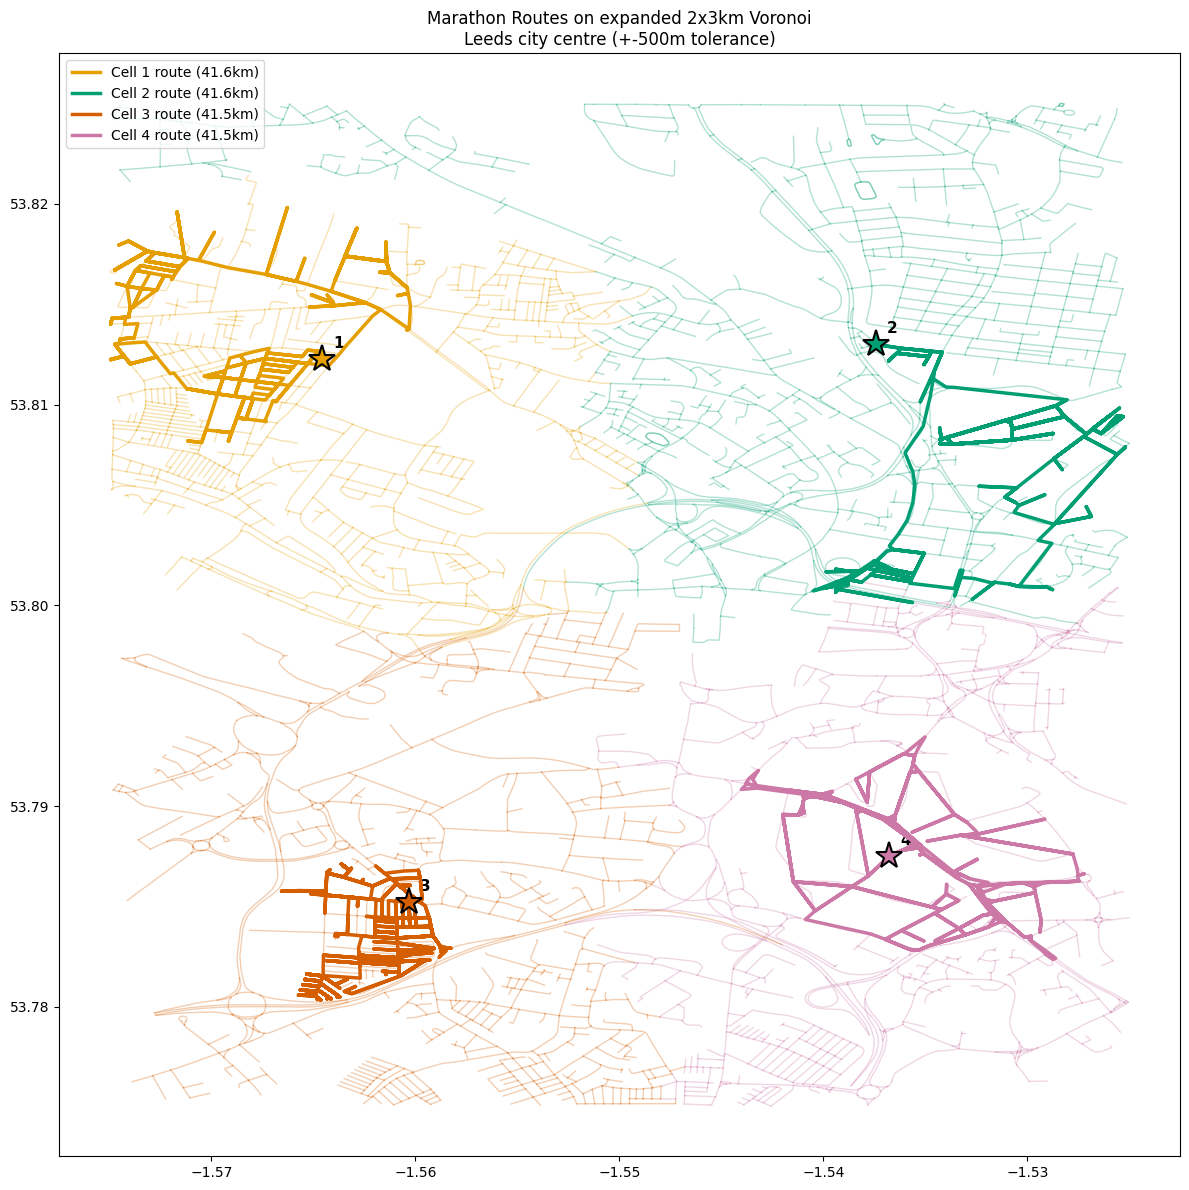

In [19]:
#to visualise found routes 
fig, ax= plt.subplots(figsize=(12,12))
#draw voronoi cell edges
for u, v, data in G_large.edges(data=True):
    cell = voronoi_large.get(u)
    colour = cell_colours[cell] if cell is not None else "gray"
    if "geometry" in data:
        xs, ys = data["geometry"].xy
        ax.plot(xs, ys, color = colour, linewidth=1, alpha= 0.3)
    else:
        ax.plot([G_large.nodes[u]["x"], G_large.nodes[v]["x"]],
                [G_large.nodes[u]["y"], G_large.nodes[v]["y"]],
                color = colour, linewidth=1, alpha=0.3)
#overlay marathon routes
for i, result in routes_large.items():
    if result is None:
        continue
    route, dist = result
    rx = [G_large.nodes[n]["x"] for n in route]
    ry = [G_large.nodes[n]["y"] for n in route]
    ax.plot(rx, ry, color = cell_colours[i], linewidth=2.5, zorder=4, label=f"Cell {i+1} route ({dist/1000:.1f}km)")

#plot seed nodes as starts *
for i, node in enumerate(seeds_large):
    x = leeds_large.nodes[node]["x"]
    y= leeds_large.nodes[node]["y"]
    ax.plot(x, y, "*", color=cell_colours[i], markersize=20, zorder=6, markeredgecolor="black", markeredgewidth=1.5)
    ax.annotate(str(i+1), (x,y), textcoords="offset points", xytext=(8,8), fontsize=11, fontweight="bold", color="black")

ax.legend(loc="upper left", frameon= True)
ax.set_title("Marathon Routes on expanded 2x3km Voronoi\n" "Leeds city centre (+-500m tolerance)")
plt.tight_layout()
plt.savefig("routes_expanded.png", dpi=150)
             

                